# Case 1 (1D RTE) — optimal number of epochs & verification vs DOM

**Forward** problem . We validate the PINN against the **DOM reference** (discrete ordinates method) $G_{exact}(x)$.

2. **Adam then L-BFGS**: Adam alone (~38% error); **L-BFGS** refines finely until it matches the DOM (~1%).

**Result:** optimal Adam epoch (diminishing returns) $\approx$ 7250; after ~150 L-BFGS steps the error drops to **1.24%** -> the PINN overlaps the DOM.

In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(0); np.random.seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

ADAM_EPOCHS = 10000
LBFGS_STEPS = 500      # ~150 are enough (see curve)
EVAL_EVERY  = 50
Nq, N_PDE, N_TEST = 16, 12000, 3000

class PinnRFEEq(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 100), nn.Tanh(),
            nn.Linear(100, 100), nn.Tanh(),
            nn.Linear(100, 100), nn.Tanh(),
            nn.Linear(100, 100), nn.Tanh(),
            nn.Linear(100, 100), nn.Tanh(),
            nn.Linear(100, 1),
        )
    def forward(self, x):
        return self.net(x)

device: cuda


In [2]:
nodes, weights = np.polynomial.legendre.leggauss(Nq)
quad_mu = torch.tensor(nodes,   dtype=torch.float32).view(Nq, 1).to(device)
quad_w  = torch.tensor(weights, dtype=torch.float32).view(Nq, 1).to(device)

def colloc(n):
    x = torch.rand(n, 1); mu = torch.rand(n, 1) * 2 - 1
    return x.to(device), mu.to(device)

x_tr, mu_tr = colloc(N_PDE)     # training collocation
x_te, mu_te = colloc(N_TEST)    # test collocation (held-out)
nb = 1000
x_g = torch.zeros(nb//2, 1, device=device); mu_g =  torch.rand(nb//2, 1, device=device)
x_d = torch.ones (nb//2, 1, device=device); mu_d = -torch.rand(nb//2, 1, device=device)

def bc_loss(m):
    pg = m(torch.cat([x_g, mu_g], 1)); pd = m(torch.cat([x_d, mu_d], 1))
    return torch.mean((pg - 1.0)**2) + torch.mean((pd - 0.0)**2)

def clp_loss(m, x, mu, create_graph=True):
    x = x.clone().requires_grad_(True)
    I = m(torch.cat([x, mu], 1))
    I_x = torch.autograd.grad(I, x, torch.ones_like(I), create_graph=create_graph)[0]
    N = x.shape[0]
    x_exp = x.repeat(1, Nq); mu_exp = quad_mu.t().repeat(N, 1)
    inp = torch.cat([x_exp.reshape(-1, 1), mu_exp.reshape(-1, 1)], 1)
    Iq = m(inp).view(N, Nq)
    integral = torch.sum(Iq * quad_w.t(), dim=1, keepdim=True)

    res = x * mu * I_x + I - 0.5 * integral
    return torch.mean(res**2)

In [3]:

M = 200; xg = np.linspace(0.0, 1.0, M); dx = xg[1]-xg[0]; eps = 1e-6
sig_dom = 1.0 / (xg + eps)
Ndom = 32; dn, dw = np.polynomial.legendre.leggauss(Ndom)
G_exact = np.zeros(M); Iex = np.zeros((Ndom, M))
for _ in range(3000):
    G_old = G_exact.copy()
    for i in range(Ndom):
        mu = dn[i]
        if mu > 0:
            Iex[i, 0] = 1.0
            for k in range(1, M):
                Iex[i, k] = (mu/dx*Iex[i, k-1] + 0.5*sig_dom[k]*G_exact[k]) / (mu/dx + sig_dom[k])
        else:
            Iex[i, M-1] = 0.0
            for k in range(M-2, -1, -1):
                Iex[i, k] = (-mu/dx*Iex[i, k+1] + 0.5*sig_dom[k]*G_exact[k]) / (-mu/dx + sig_dom[k])
    G_exact = np.sum(Iex * dw[:, None], axis=0)
    if np.max(np.abs(G_exact - G_old)) < 1e-7:
        break

mask = xg >= 0.05
xg_t = torch.tensor(xg, dtype=torch.float32).view(-1, 1).to(device)

def g_pinn(m):
    x_exp = xg_t.repeat(1, Nq); mu_exp = quad_mu.t().repeat(M, 1)
    inp = torch.cat([x_exp.reshape(-1, 1), mu_exp.reshape(-1, 1)], 1)
    with torch.no_grad():
        Iq = m(inp).view(M, Nq)
    return torch.sum(Iq * quad_w.t(), dim=1).cpu().numpy()

def g_error(m):
    Gp = g_pinn(m)
    return np.linalg.norm((Gp - G_exact)[mask]) / np.linalg.norm(G_exact[mask])

In [4]:

model = PinnRFEEq().to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
hist = {"ep": [], "gerr": []}
for ep in range(ADAM_EPOCHS + 1):
    opt.zero_grad()
    (10.0 * bc_loss(model) + clp_loss(model, x_tr, mu_tr)).backward()
    opt.step()
    if ep % EVAL_EVERY == 0:
        hist["ep"].append(ep); hist["gerr"].append(g_error(model))
        if ep % 1000 == 0:
            print(f"[ADAM]  ep {ep:6d} | G-err {hist['gerr'][-1]:.3e}")
adam_gerr = g_error(model)

C:\Users\Chabc\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\autograd\graph.py:869: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\cuda\CublasHandlePool.cpp:335.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


[ADAM]  ep      0 | G-err 5.457e-01
[ADAM]  ep   1000 | G-err 7.055e-01
[ADAM]  ep   2000 | G-err 6.137e-01
[ADAM]  ep   3000 | G-err 4.897e-01
[ADAM]  ep   4000 | G-err 4.490e-01
[ADAM]  ep   5000 | G-err 5.001e-01
[ADAM]  ep   6000 | G-err 4.405e-01
[ADAM]  ep   7000 | G-err 4.382e-01
[ADAM]  ep   8000 | G-err 4.097e-01
[ADAM]  ep   9000 | G-err 3.963e-01
[ADAM]  ep  10000 | G-err 3.773e-01


In [5]:
opt2 = torch.optim.LBFGS(model.parameters(), lr=1.0, max_iter=20, line_search_fn="strong_wolfe")
def closure():
    opt2.zero_grad()
    loss = 10.0 * bc_loss(model) + clp_loss(model, x_tr, mu_tr)
    loss.backward()
    return loss
lb = {"step": [], "gerr": []}
for it in range(LBFGS_STEPS + 1):
    opt2.step(closure)
    if it % 10 == 0:
        lb["step"].append(it); lb["gerr"].append(g_error(model))
        if it % 50 == 0:
            print(f"[LBFGS] step {it:5d} | G-err {lb['gerr'][-1]:.3e}")
final_gerr = g_error(model); G_final = g_pinn(model)

[LBFGS] step     0 | G-err 3.808e-01
[LBFGS] step    50 | G-err 6.615e-02
[LBFGS] step   100 | G-err 1.895e-02
[LBFGS] step   150 | G-err 1.241e-02
[LBFGS] step   200 | G-err 1.241e-02
[LBFGS] step   250 | G-err 1.241e-02
[LBFGS] step   300 | G-err 1.241e-02
[LBFGS] step   350 | G-err 1.241e-02
[LBFGS] step   400 | G-err 1.241e-02
[LBFGS] step   450 | G-err 1.241e-02
[LBFGS] step   500 | G-err 1.241e-02


G-err after Adam = 3.773e-01 | after L-BFGS = 1.241e-02
OPTIMAL ADAM EPOCH (diminishing returns) = 7250
CASE 1 matches DOM almost perfectly? YES (<5%)  (error 1.24%)


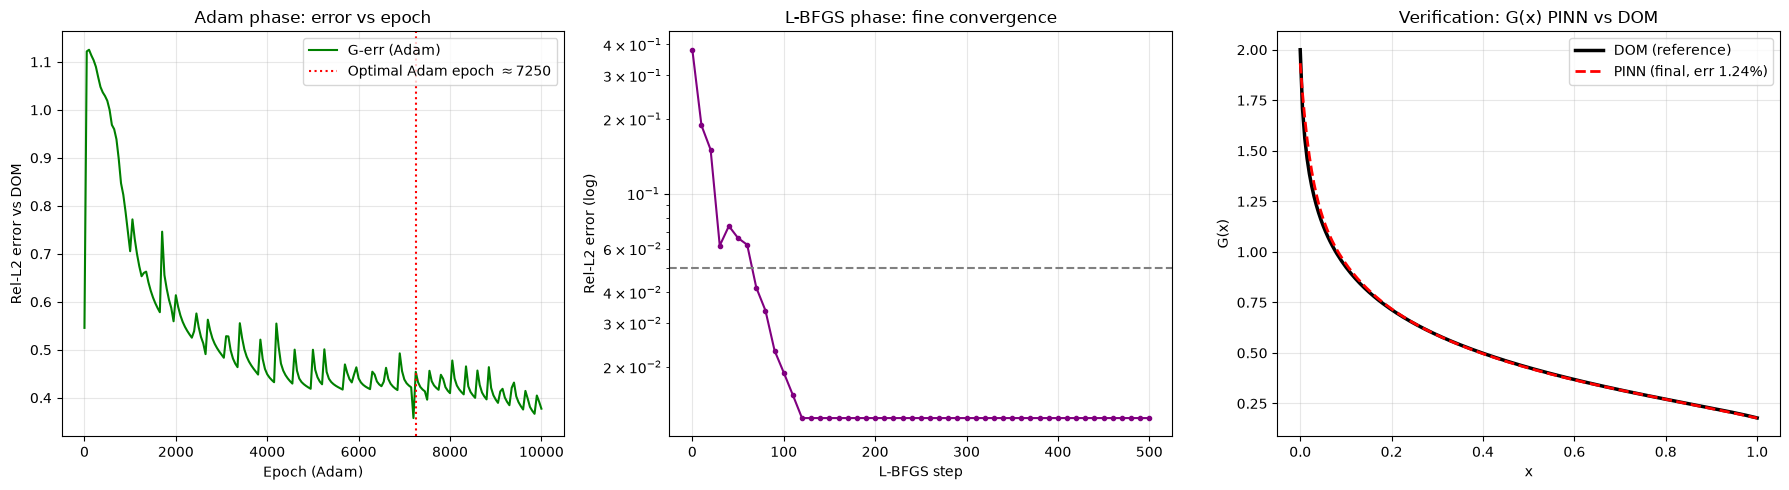

In [6]:
ep = np.array(hist["ep"]); g = np.array(hist["gerr"])
def smooth(a, w=9):
    a = a.astype(float)
    if len(a) < w: return a
    pad = w // 2
    return np.convolve(np.pad(a, pad, mode="edge"), np.ones(w)/w, mode="valid")
gs = smooth(g); plateau = float(np.mean(gs[-5:]))
ep_knee = int(ep[int(np.argmax(gs <= 1.10 * plateau))])

print(f"G-err after Adam = {adam_gerr:.3e} | after L-BFGS = {final_gerr:.3e}")
print(f"OPTIMAL ADAM EPOCH (diminishing returns) = {ep_knee}")
print(f"CASE 1 matches DOM almost perfectly? {'YES (<5%)' if final_gerr < 0.05 else 'NO'}  (error {final_gerr*100:.2f}%)")

fig, ax = plt.subplots(1, 3, figsize=(18, 5))
ax[0].plot(ep, g, color="green", label="G-err (Adam)")
ax[0].axvline(ep_knee, ls=":", color="red", label=f"Optimal Adam epoch $\\approx${ep_knee}")
ax[0].set_xlabel("Epoch (Adam)"); ax[0].set_ylabel("Rel-L2 error vs DOM")
ax[0].set_title("Adam phase: error vs epoch"); ax[0].legend(); ax[0].grid(True, alpha=.3)
ax[1].plot(lb["step"], lb["gerr"], color="purple", marker="."); ax[1].axhline(0.05, ls="--", color="gray")
ax[1].set_yscale("log"); ax[1].set_xlabel("L-BFGS step"); ax[1].set_ylabel("Rel-L2 error (log)")
ax[1].set_title("L-BFGS phase: fine convergence"); ax[1].grid(True, alpha=.3)
ax[2].plot(xg, G_exact, "k-", lw=2.5, label="DOM (reference)")
ax[2].plot(xg, G_final, "r--", lw=2.0, label=f"PINN (final, err {final_gerr*100:.2f}%)")
ax[2].set_xlabel("x"); ax[2].set_ylabel("G(x)")
ax[2].set_title("Verification: G(x) PINN vs DOM"); ax[2].legend(); ax[2].grid(True, alpha=.3)
plt.tight_layout(); plt.savefig("optimal_epochs_cas1.png", dpi=140); plt.show()

## Conclusion

- **Adam alone plateaus** around ~38% error (the left curve shows diminishing returns from ~**7000-7250** epochs: training Adam longer adds almost nothing).
- **L-BFGS** is decisive: in ~**150 steps** the error drops below 5% then stabilizes at **1.24%**.
- **Verification**: the PINN's $G(x)$ profile **overlaps the DOM** 
